In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
def removeFileEuropenComma(filePath: str, outputPath: str) -> None:
    with open(filePath, "r", encoding="utf-8") as fIn:
        with open(outputPath, "w", encoding="utf-8") as fOut:
            for line in fIn:
                fOut.write(line.replace(",", "."))


def getDataset(basePath: str) -> dict[int, np.ndarray[float]]:
  datasets = {}
  for dataFile in os.listdir(basePath):
      filePath = os.path.join(basePath, dataFile)

      datasets[dataFile] = np.genfromtxt(filePath, delimiter=",", skip_header=1)

  return datasets

In [30]:
sns.set_theme(style="white")  # plot style

plt.rcParams.update({
    "font.size":         8,
    "font.family":       "DejaVu Sans",
    "font.sans-serif":   ["Alegreya Sans", "Alegreya"],
    "figure.autolayout": True,
    "figure.dpi":        300,
    "figure.figsize":    (12, 6), # wymiary wykresu
    "xtick.color":       "black",
})

sns.set_palette([
    "#525174",
    "#EC7357",
    "#6DA34D",
    "#2D93AD",
    "#A3A6F1",
    "#B5566A", 
    "#FEC601",
])


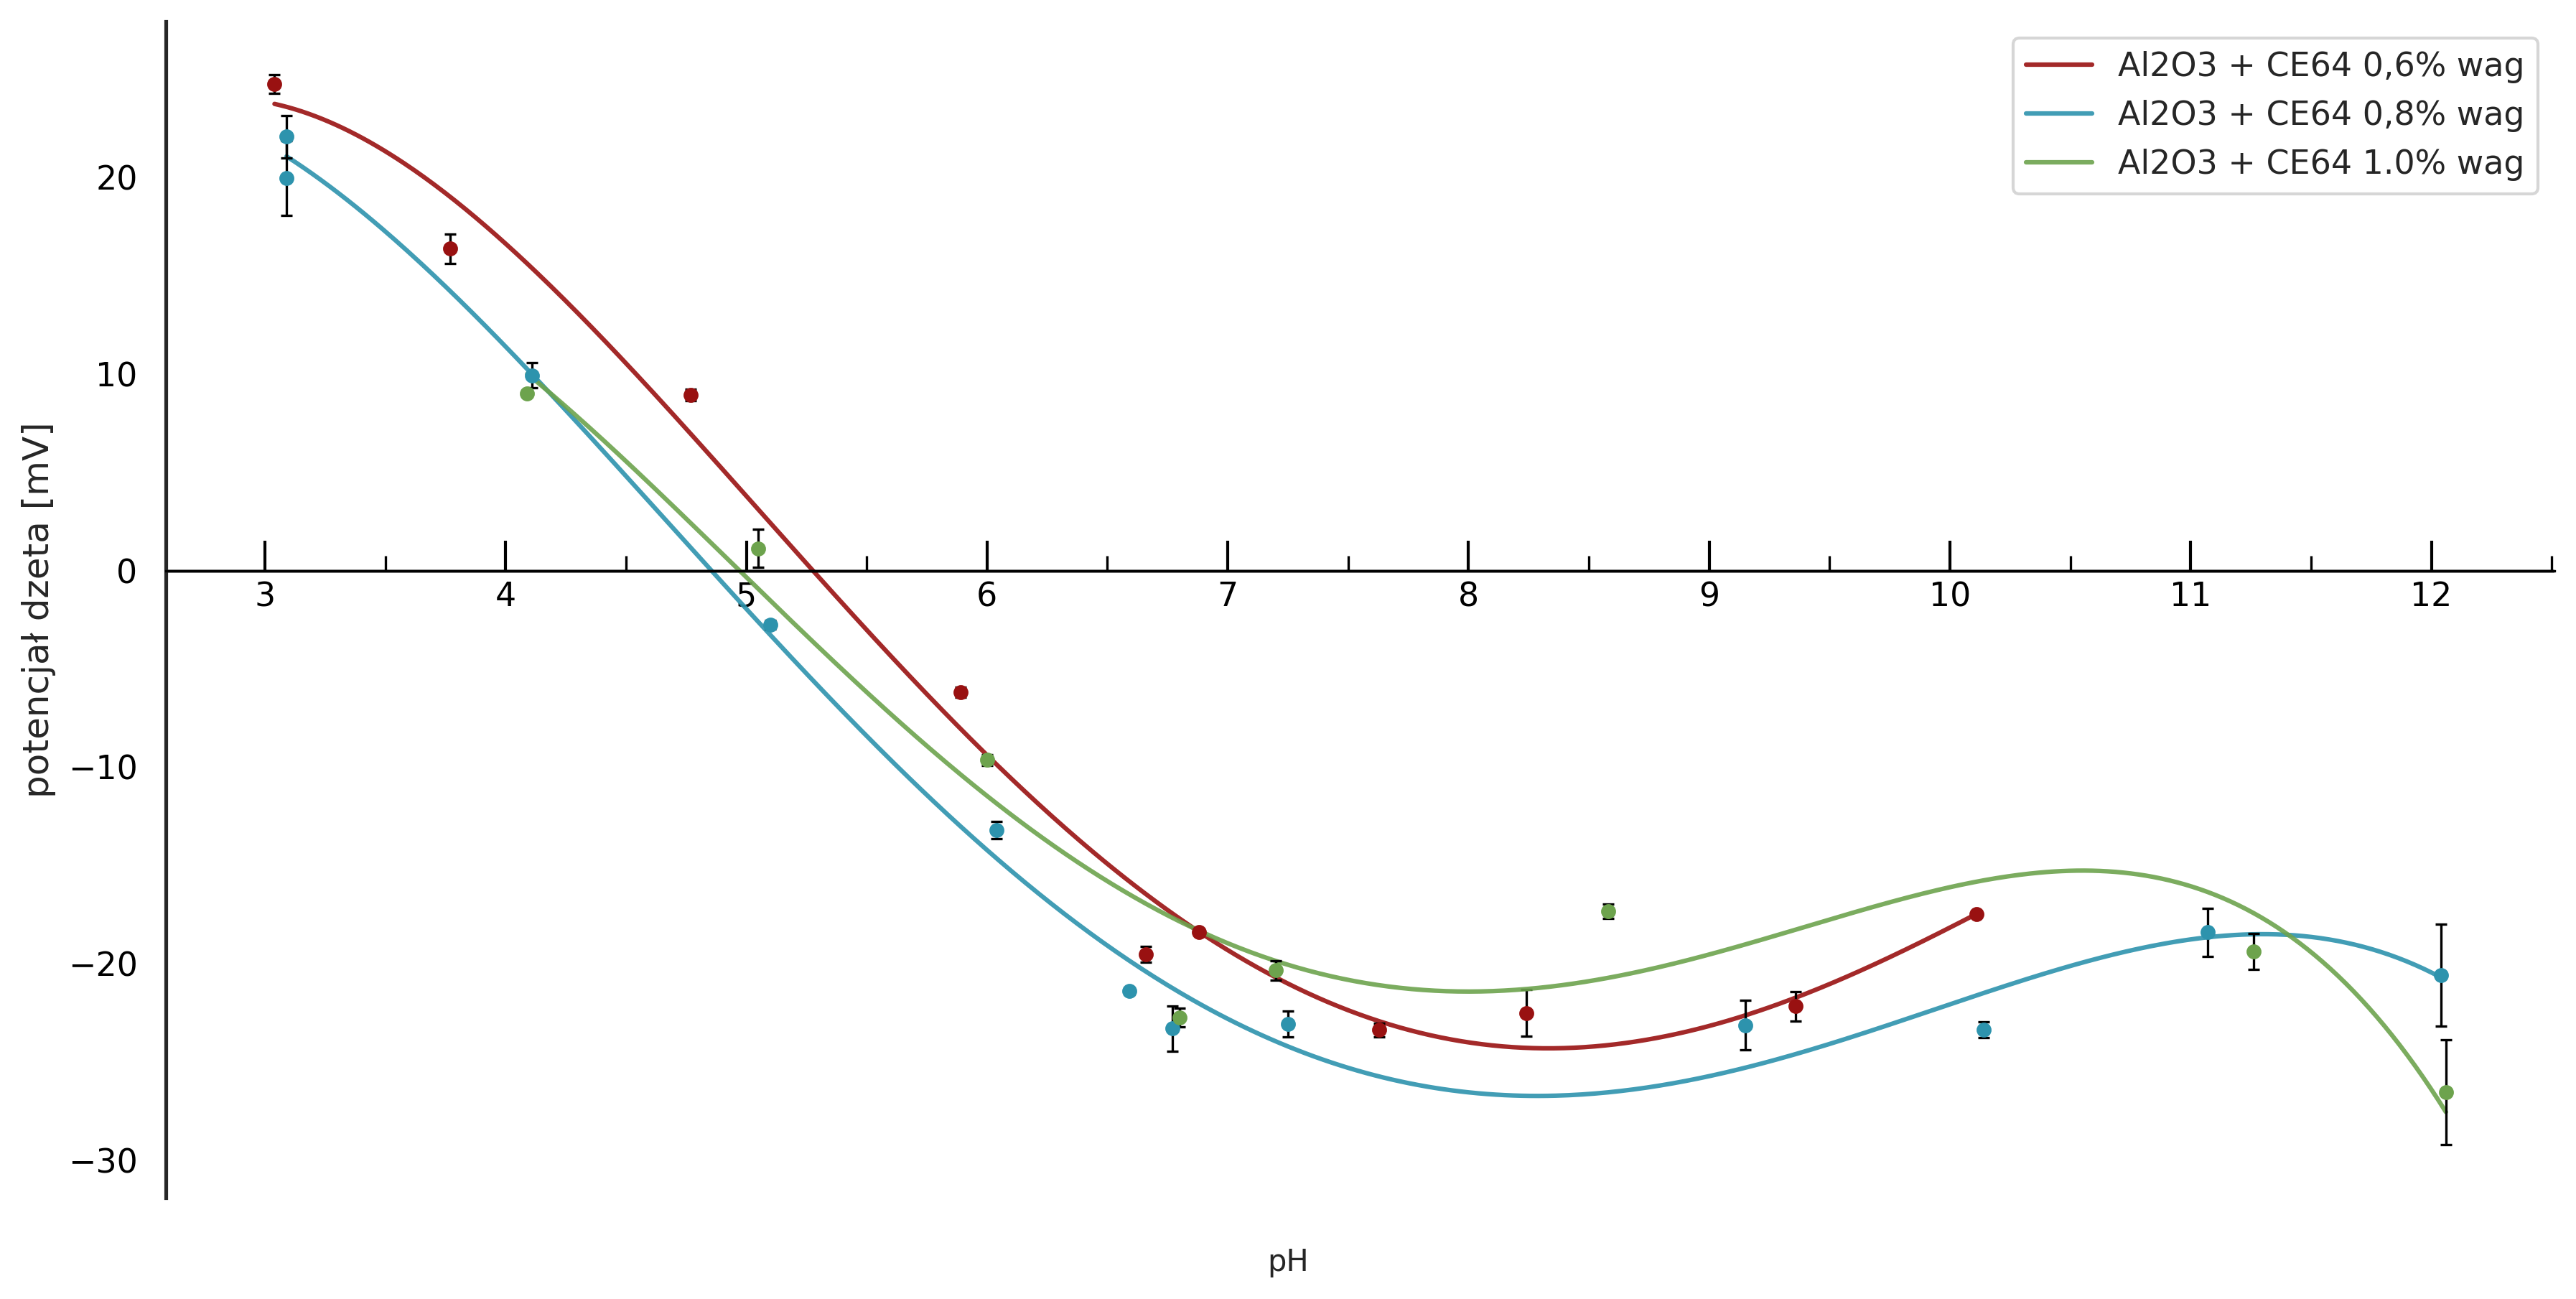

C:\Users\kucin\AppData\Local\Temp\ipykernel_19164\3019024773.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


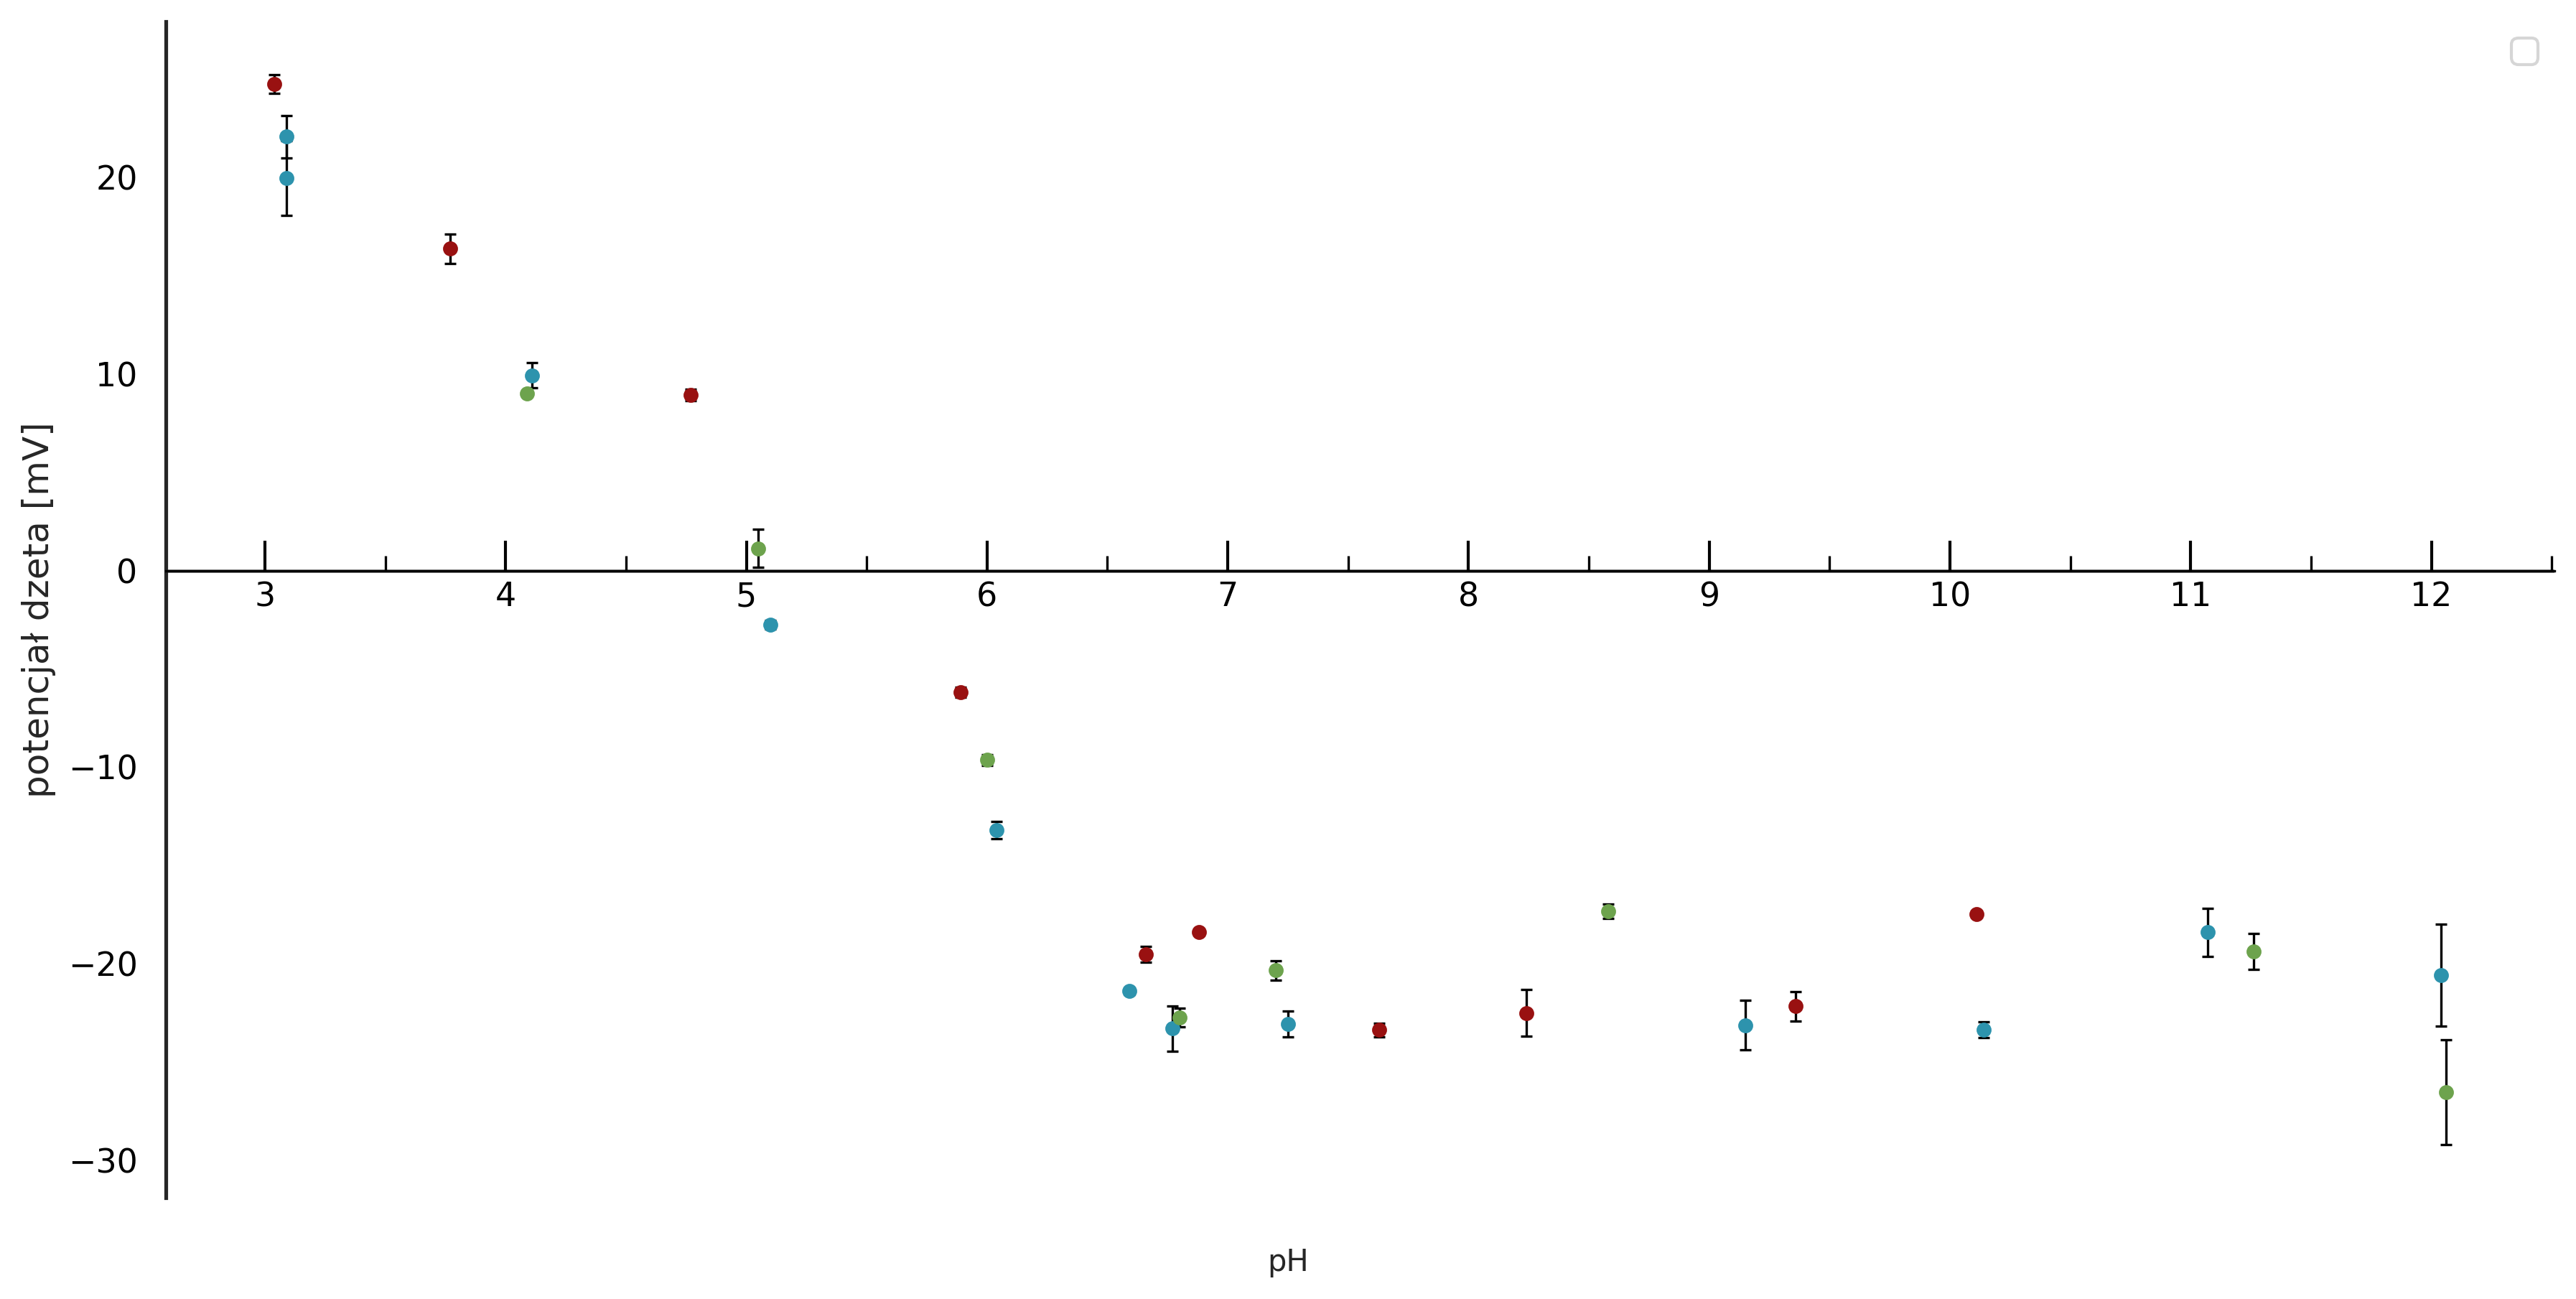

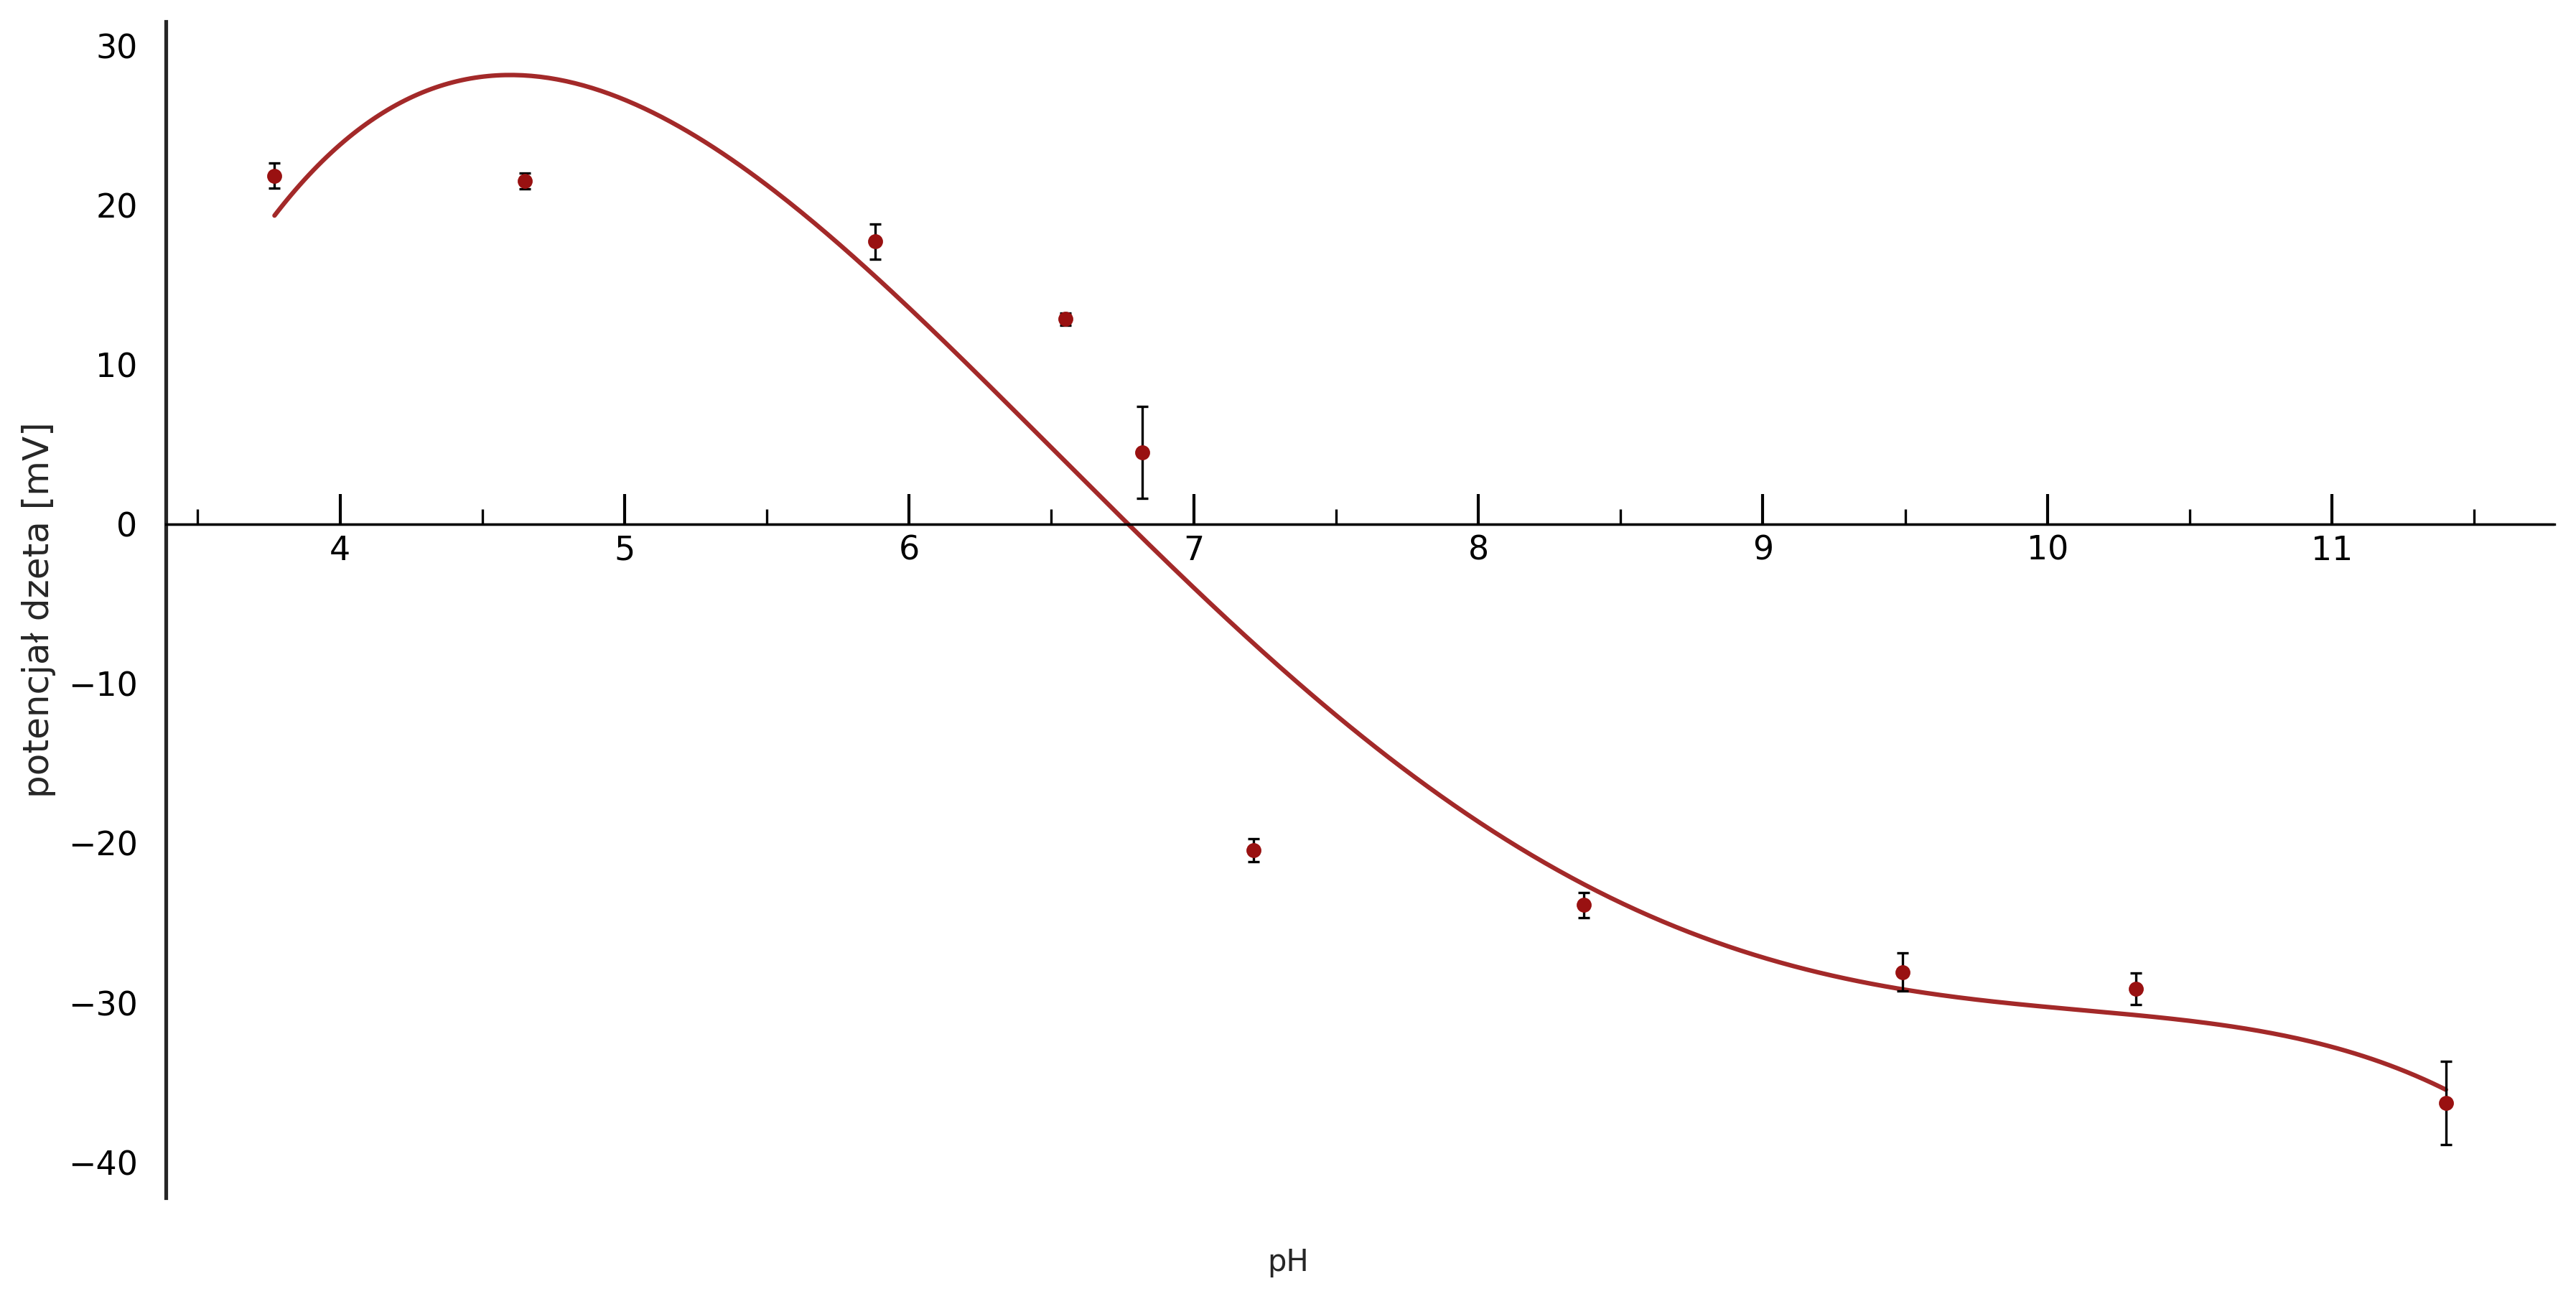

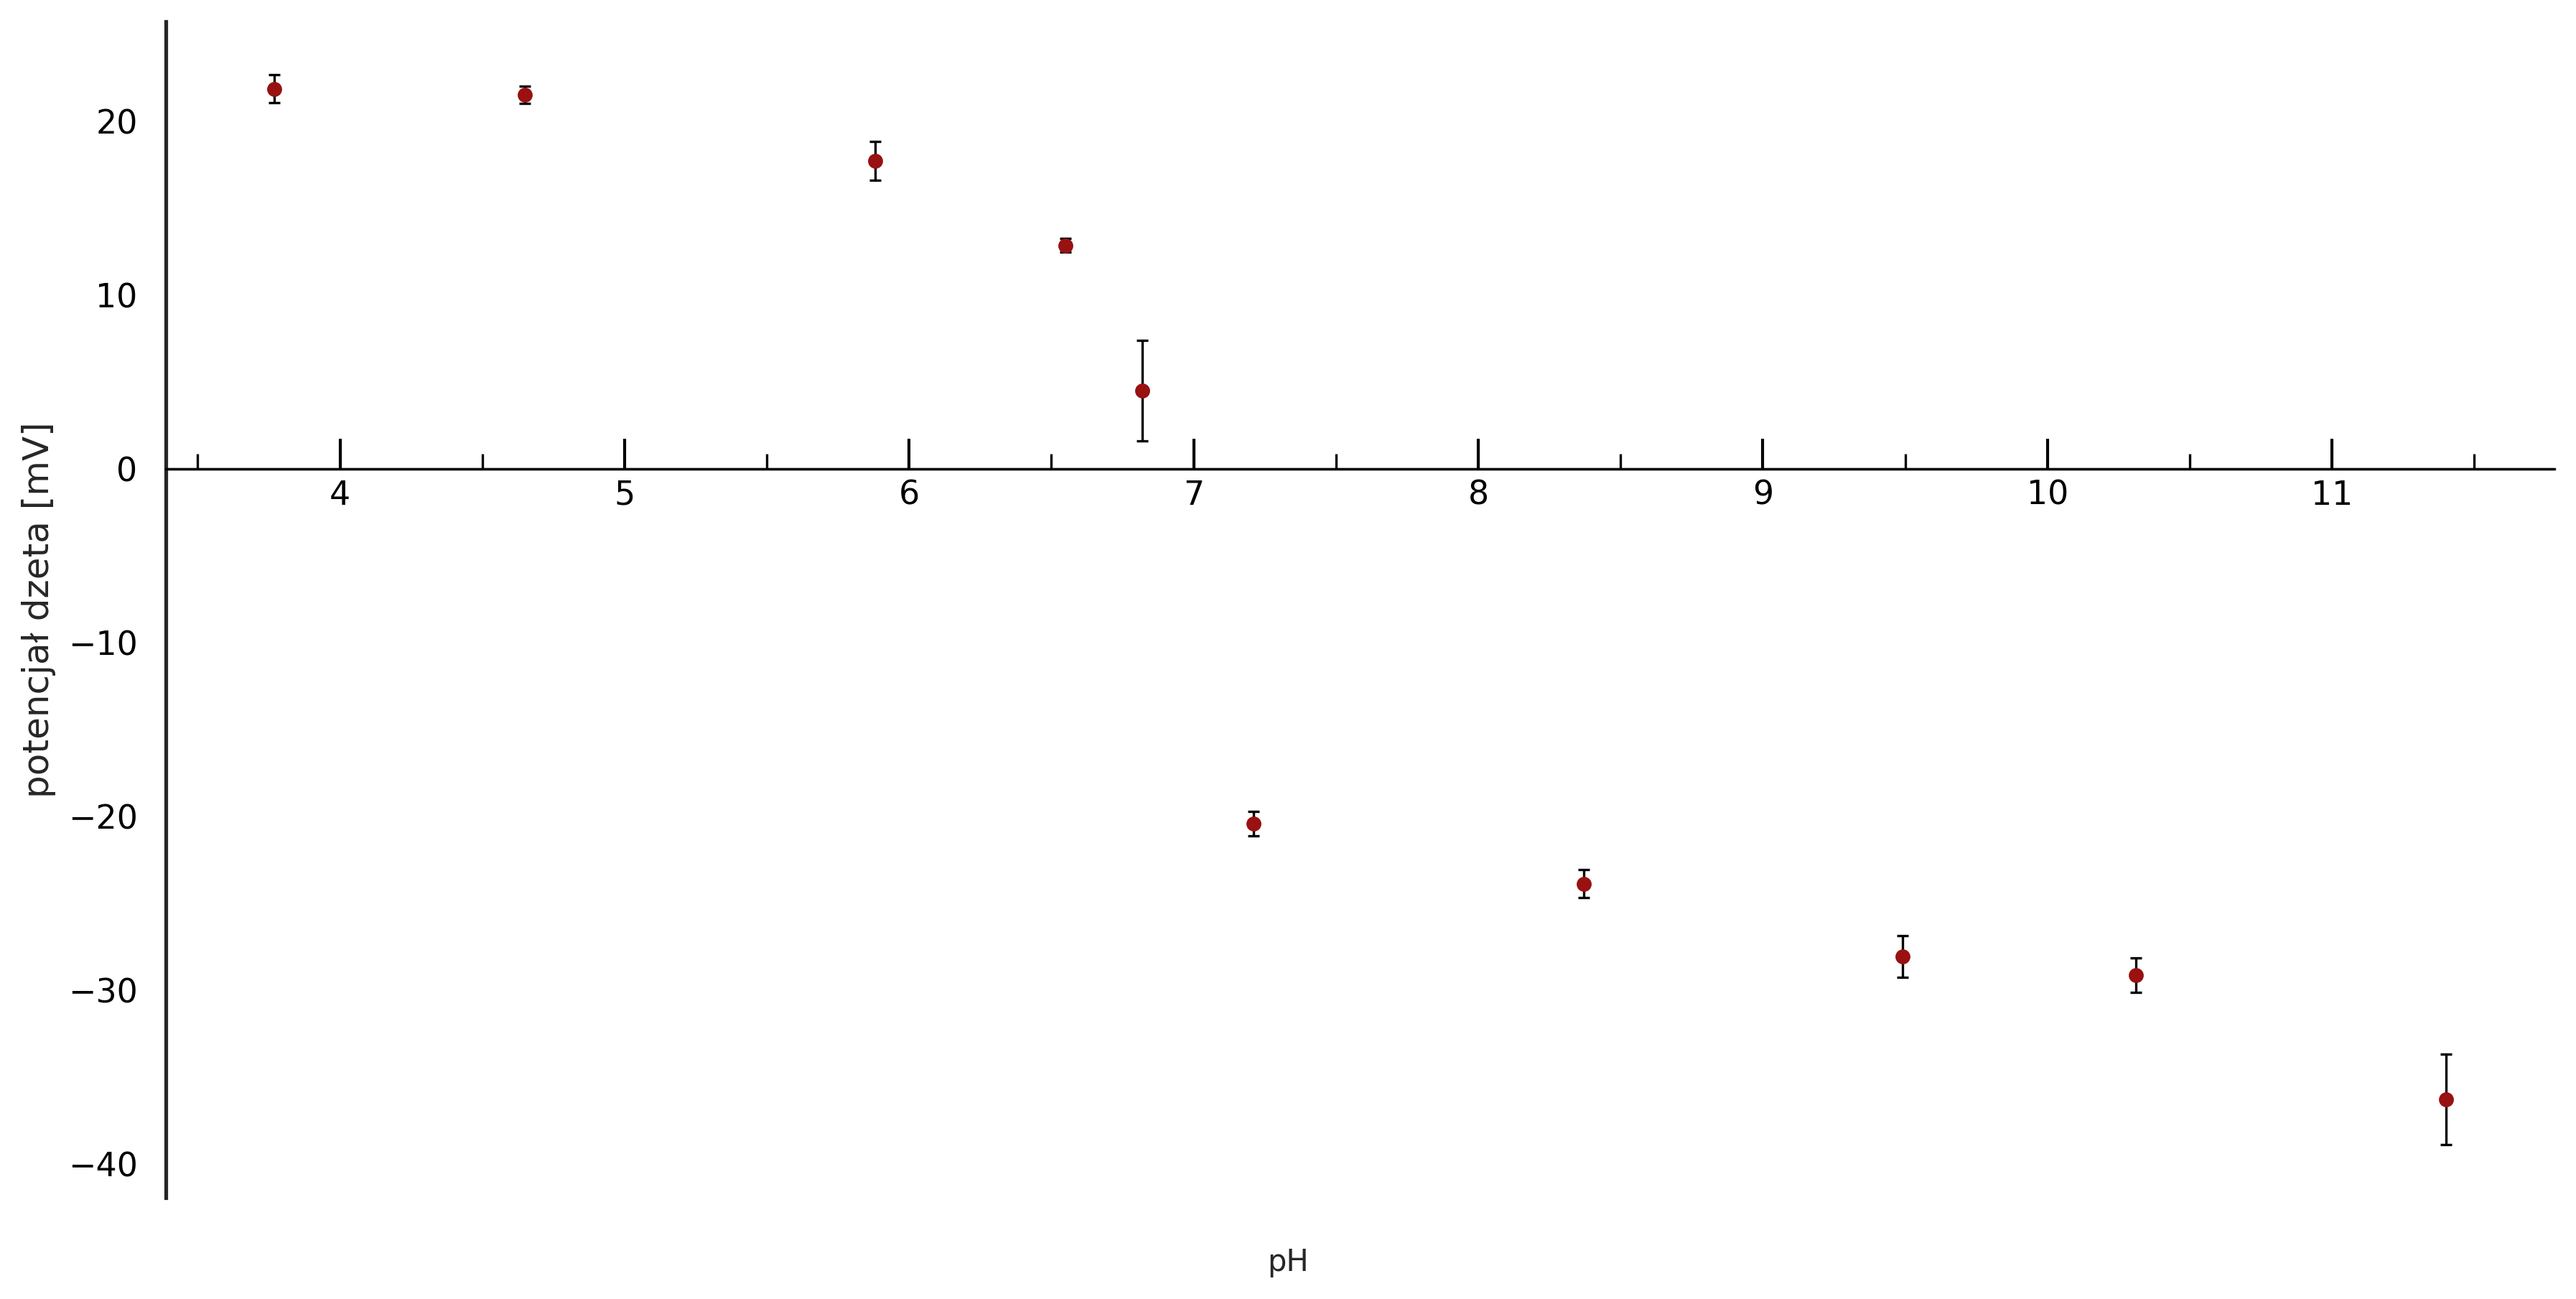

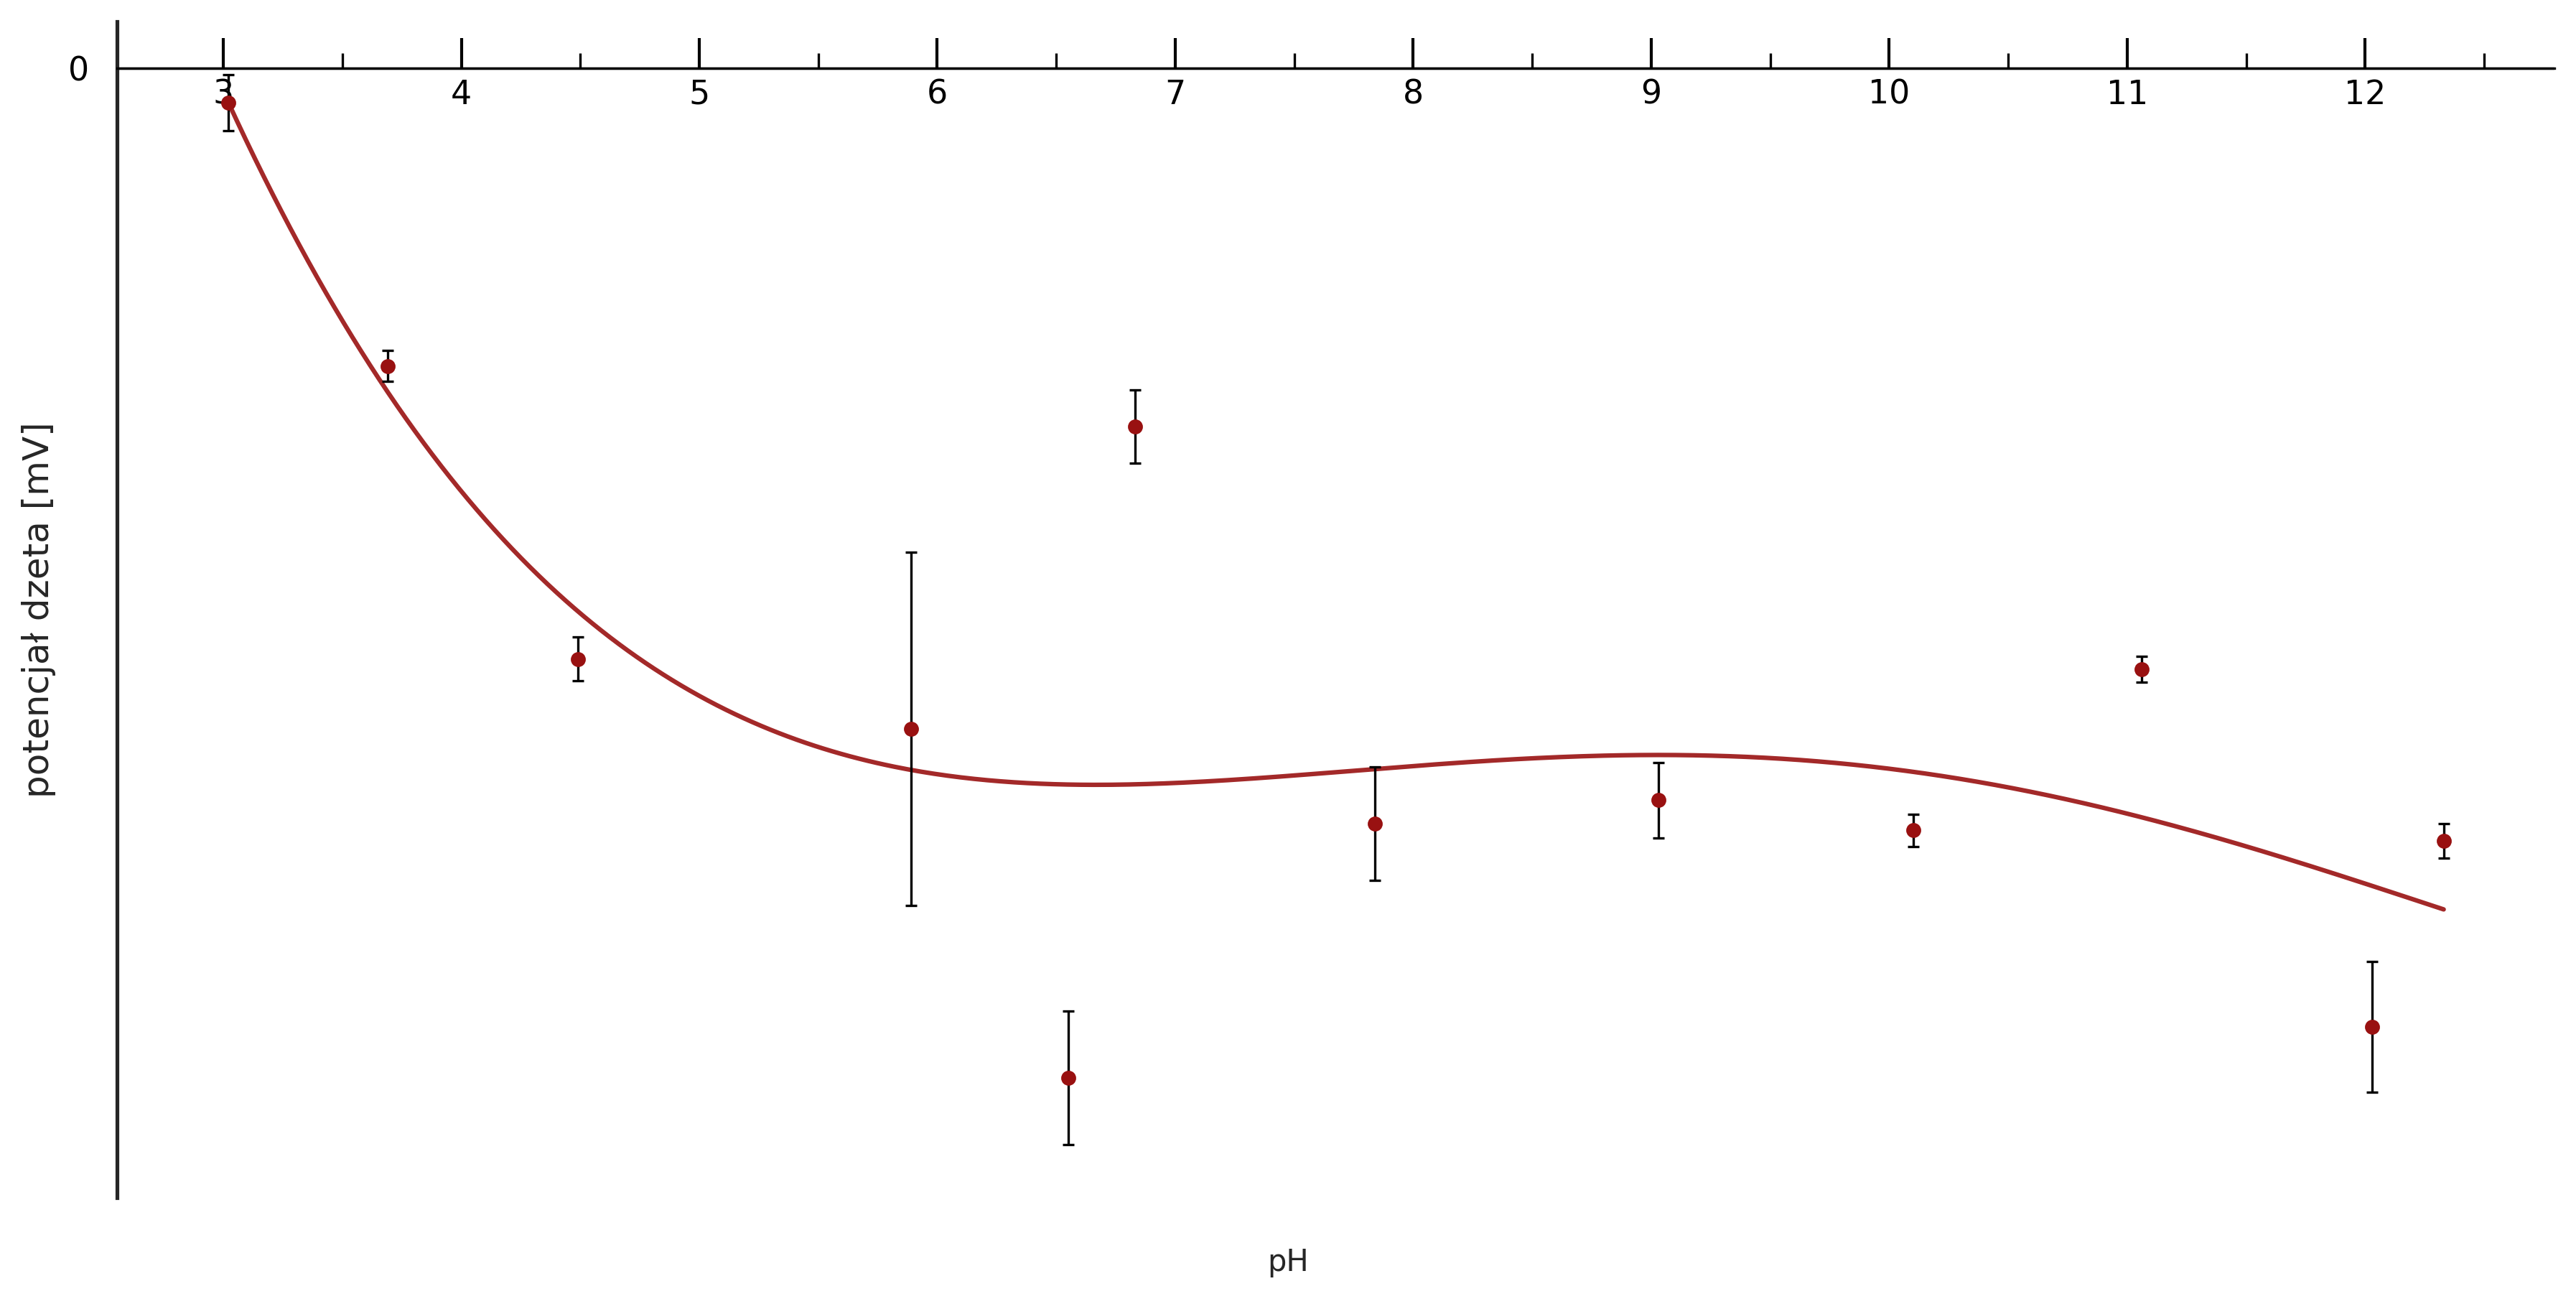

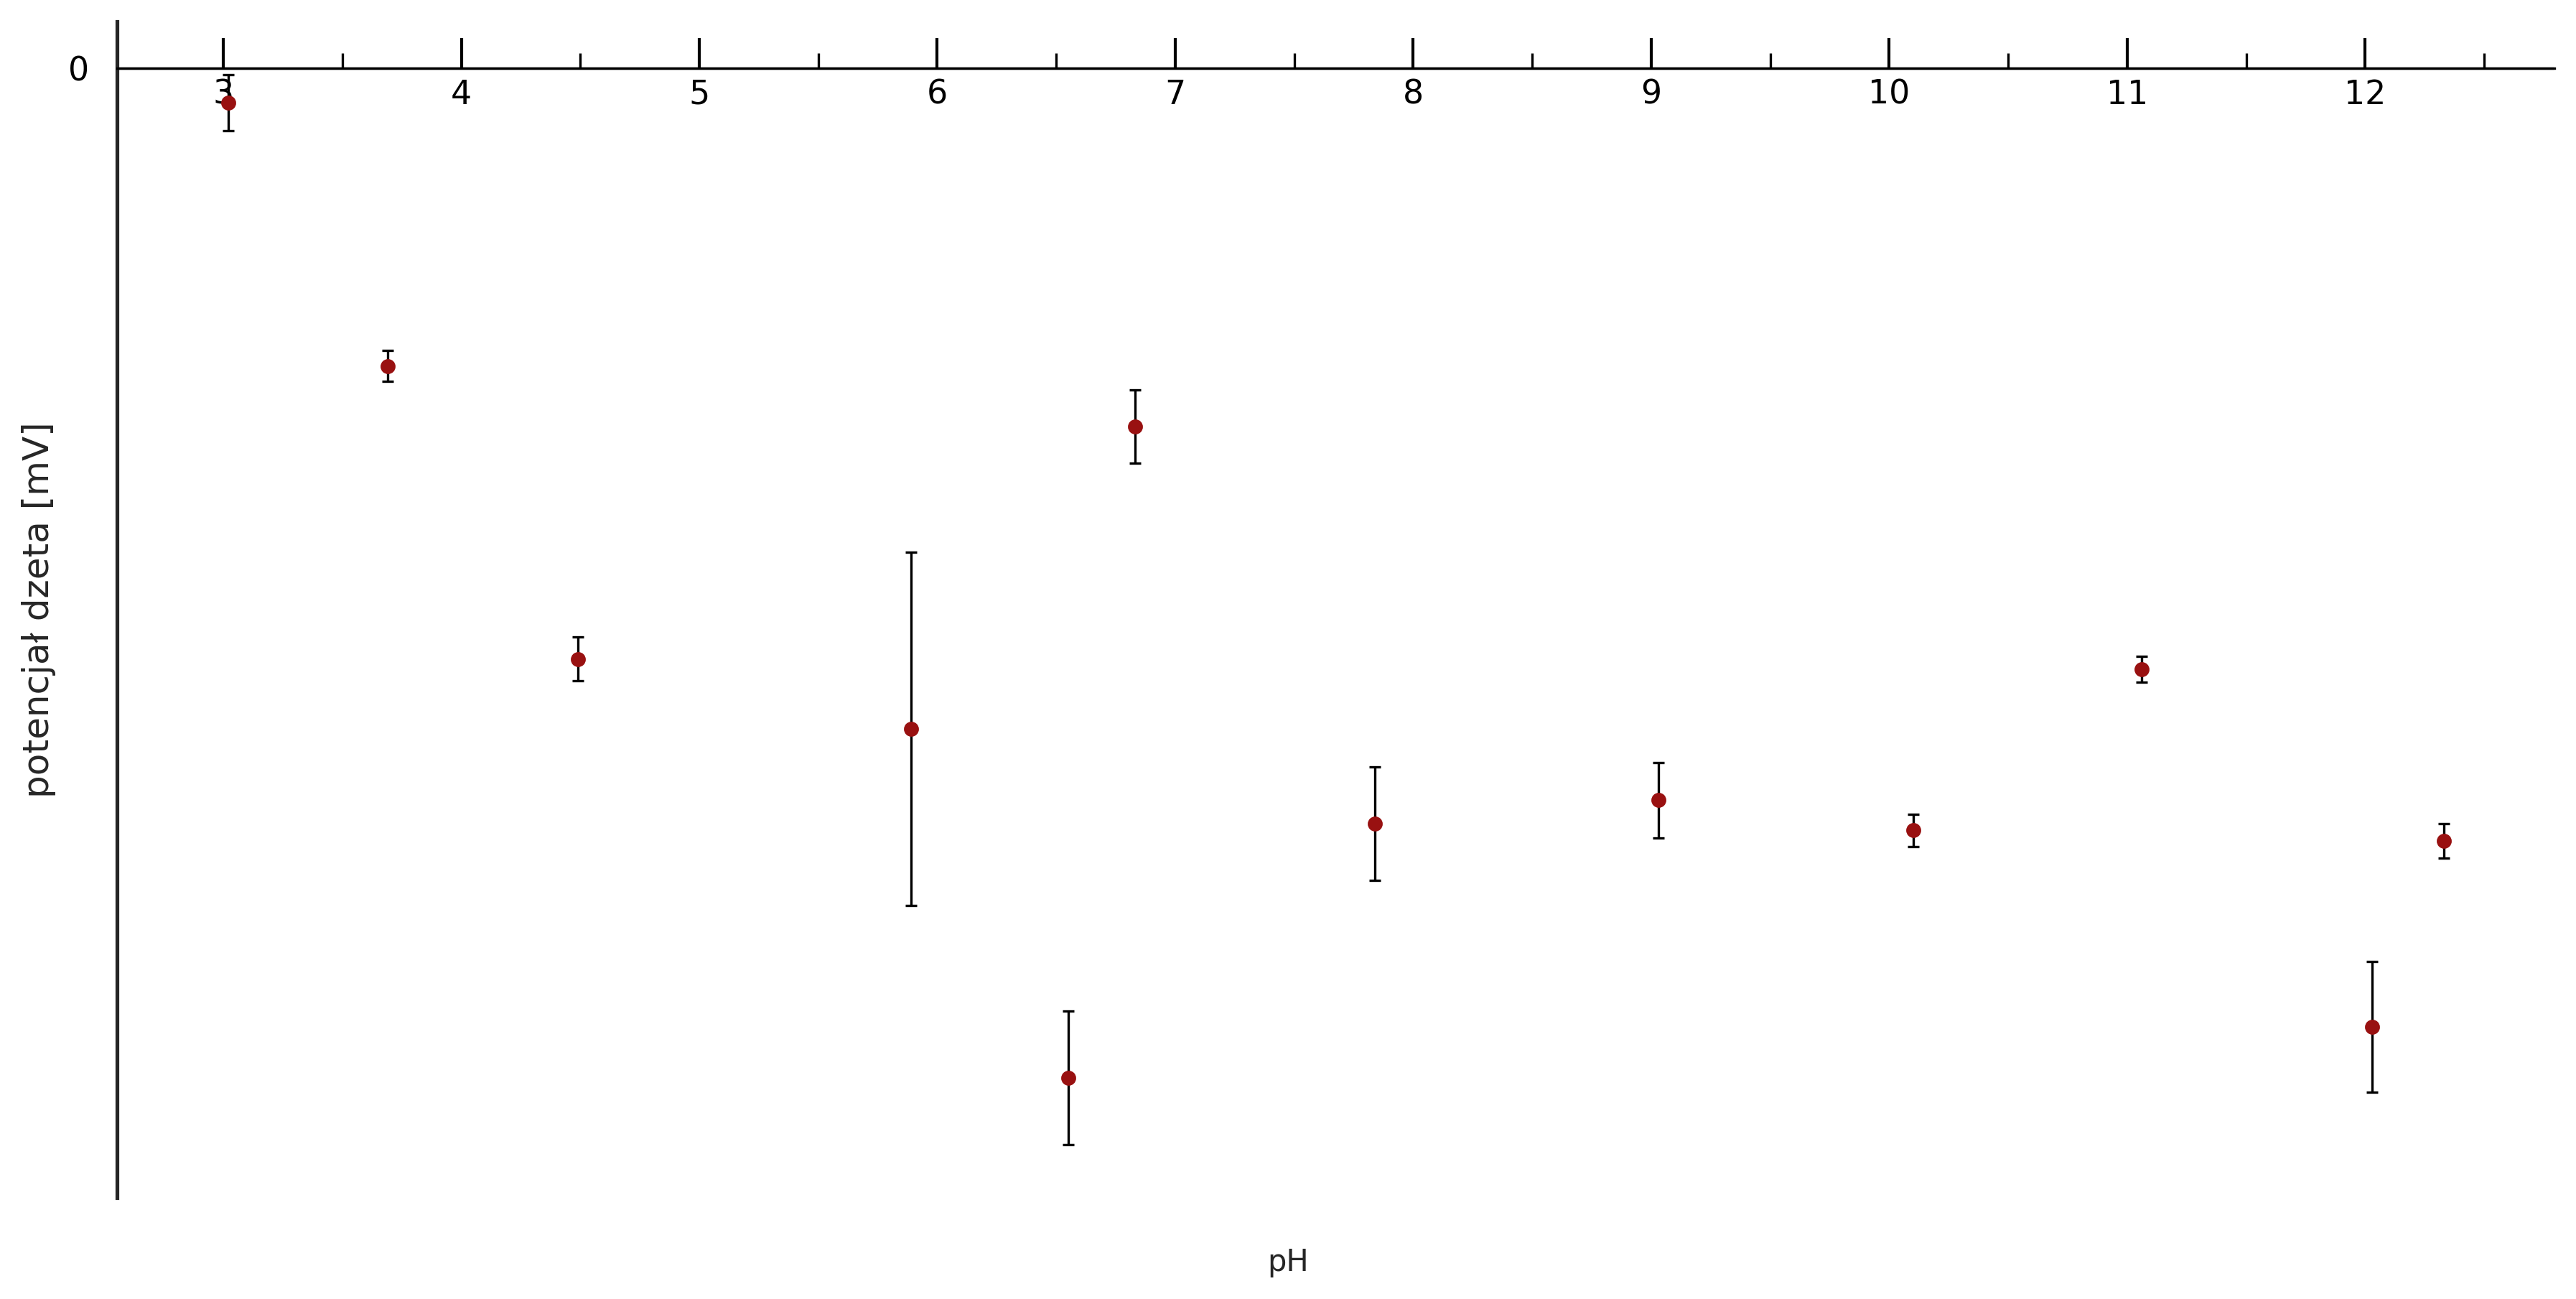

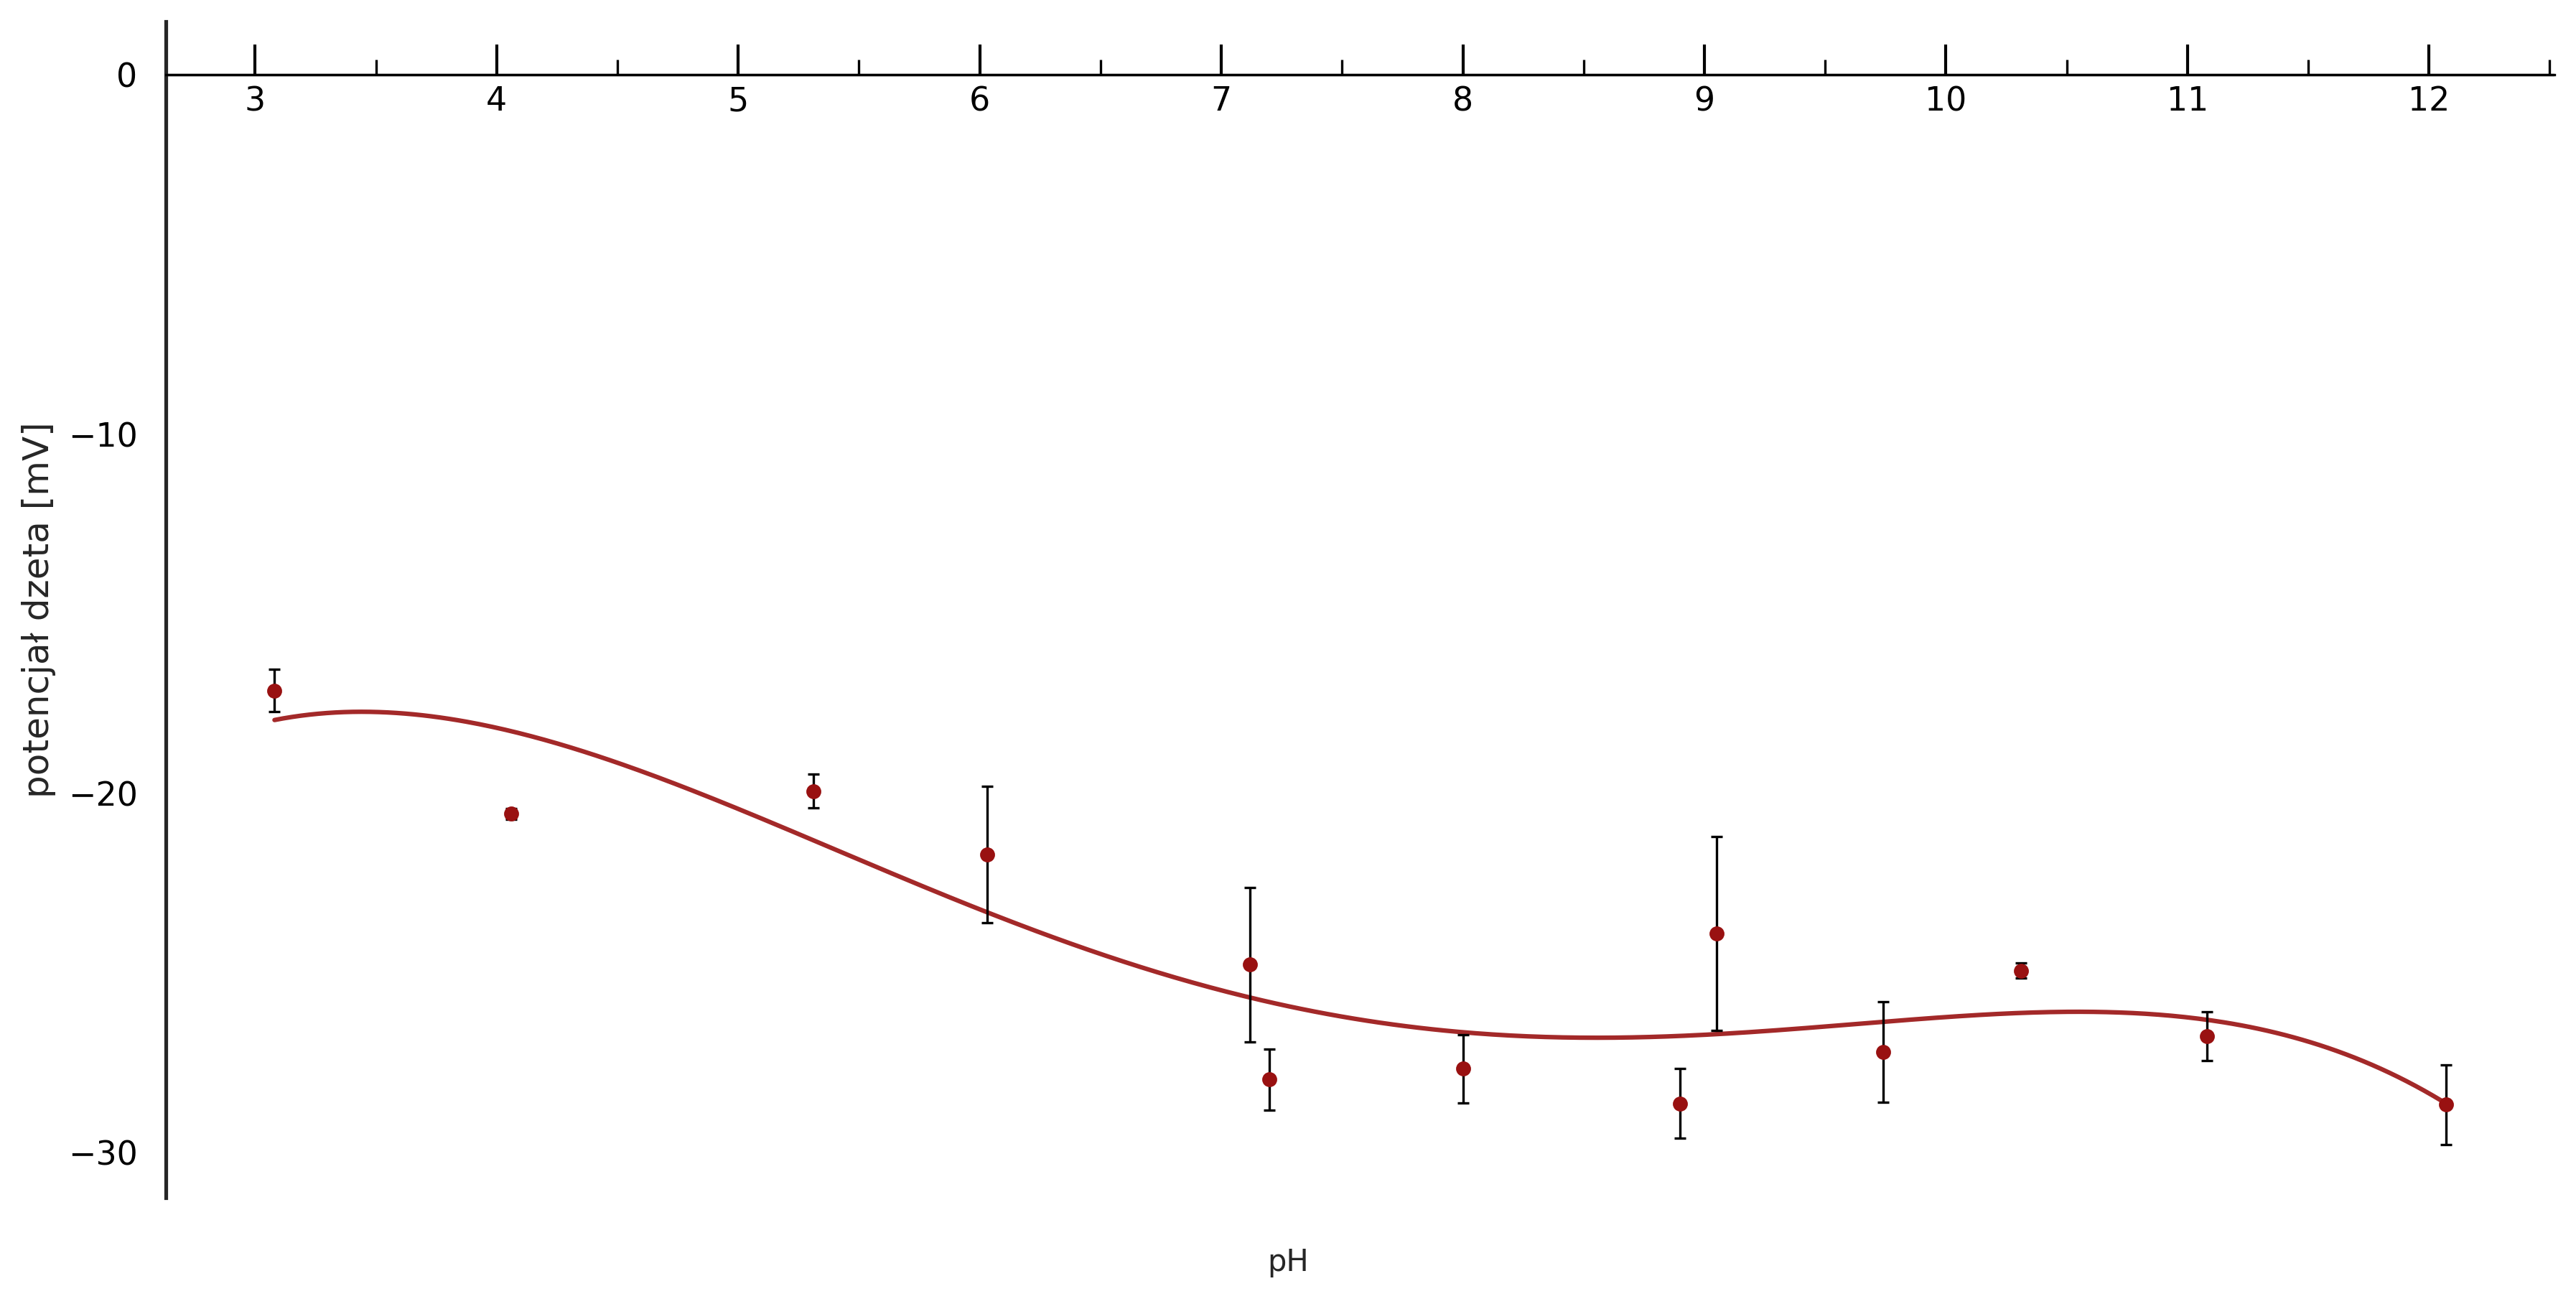

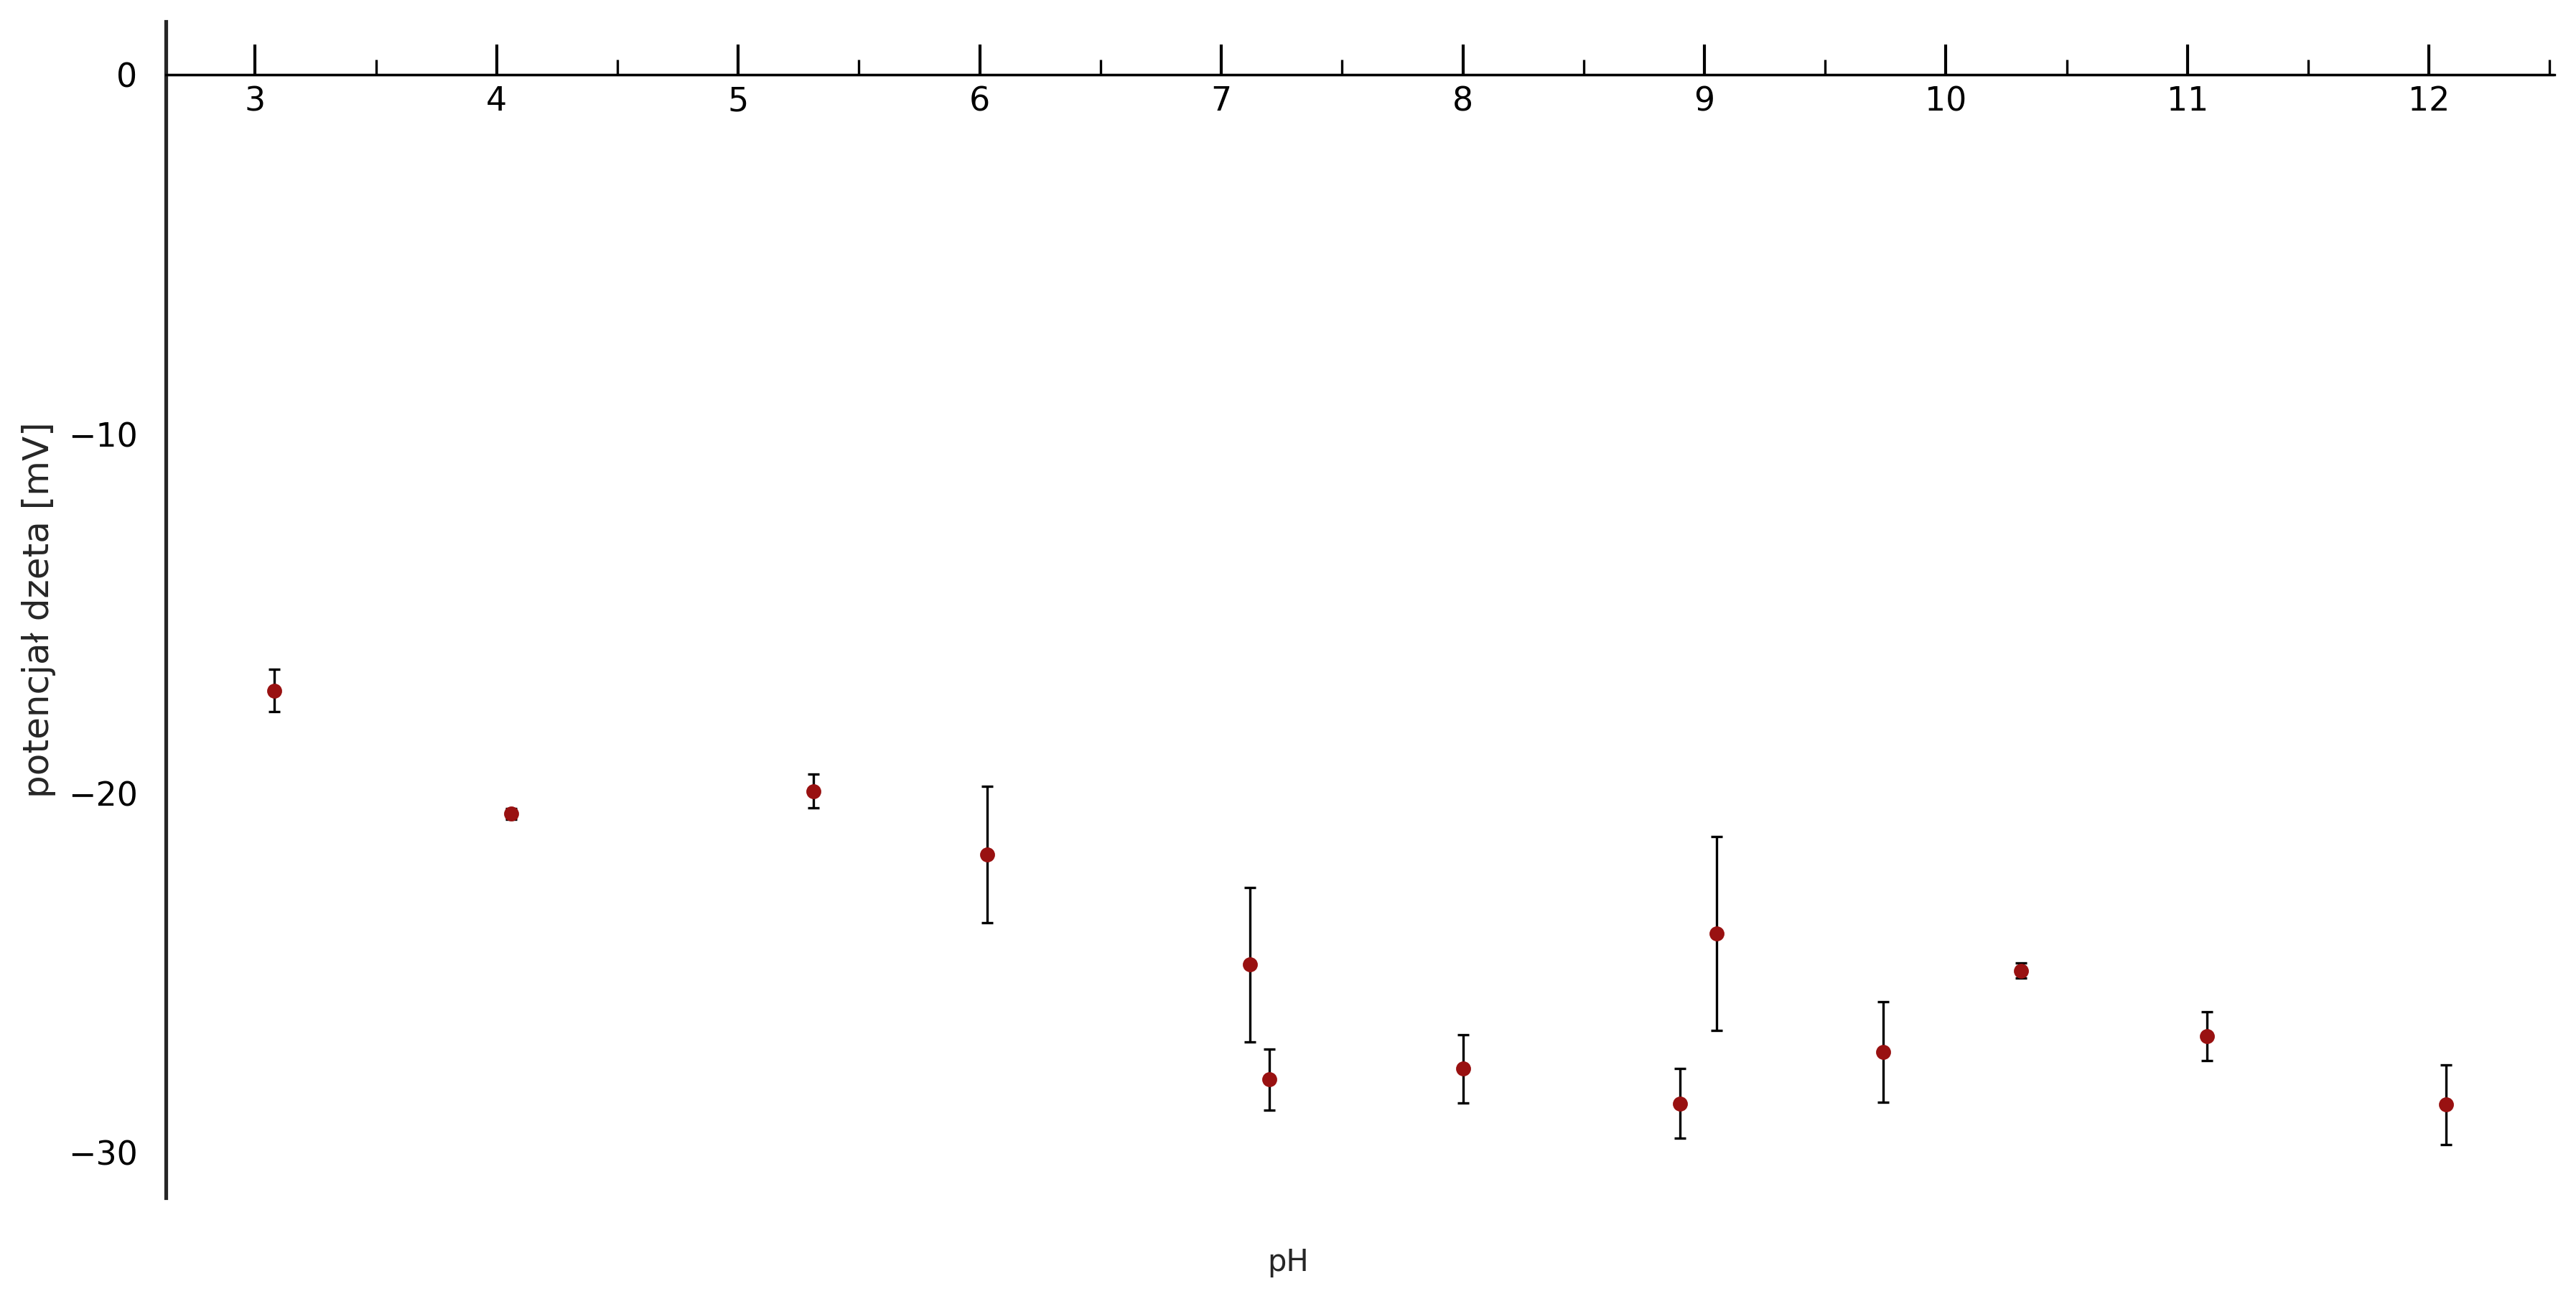

In [34]:
from matplotlib.axes import Axes
from matplotlib.ticker import AutoMinorLocator, MultipleLocator


def plot_single_dataset(
    axis: Axes,
    dataset: np.ndarray,
    poly_degree: int | None,
    color: str,
    label: str,
) -> None:
  x = dataset[:, 0] # ph
  y = dataset[:, 1] # zeta
  sigma = dataset[:, 2] # odchylenie

  # standard trendline fit
  x_sorted = np.asarray(x, dtype=float)
  y_sorted = np.asarray(y, dtype=float)

  # wielomianowa interpolacja
  if poly_degree is not None and len(x_sorted) > 2:
      x_interp = np.linspace(x_sorted.min(), x_sorted.max(), 500)
      degree = min(poly_degree, len(x_sorted) - 1)
      coeffs = np.polyfit(x_sorted, y_sorted, degree)
      y_interp = np.polyval(coeffs, x_interp)
      axis.plot(x_interp, y_interp, color=color, linewidth=1.5, alpha=0.9, label=label)

  # sigma error bars relative to y
  axis.errorbar(
      x, y,
      yerr=sigma,
      markersize=4,
      linestyle="none",
      color=color,
      ecolor="#000000",
      elinewidth=0.8,
      capsize=2,
      capthick=0.8,
      fmt="o",
  )

  axis.set_ylabel('potencjał dzeta [mV]')

  # x-axis with ticks and numbers on y = 0
  axis.spines['bottom'].set_position(('data', 0))
  axis.spines['bottom'].set_linewidth(0.8)
  axis.spines['bottom'].set_color('black')
  axis.xaxis.set_ticks_position('bottom')

  axis.spines['top'].set_visible(False)
  axis.spines['right'].set_visible(False)

  # draw the zero line and hide the default x-axis label title
  axis.axhline(0, color='black', linewidth=0.8)
  axis.xaxis.label.set_visible(False)

  # drobne ticki
  axis.tick_params(axis='x', which='major', length=10, width=1, direction='in', colors='black')
  axis.tick_params(axis='x', which='minor', length=5, width=0.8, direction='in', colors='black')
  axis.tick_params(axis='y', which='major', length=6, width=0.8, direction='out', colors='black')
  axis.tick_params(axis='y', which='minor', length=3, width=0.6, direction='out', colors='black')

  axis.xaxis.set_major_locator(MultipleLocator(1))
  axis.xaxis.set_minor_locator(AutoMinorLocator(2))
  axis.yaxis.set_major_locator(MultipleLocator(10))
  axis.yaxis.set_minor_locator(AutoMinorLocator(5))


def plotDataset(
    datasets: dict[str, np.ndarray],
    labels: list[str],
    *,
    poly_degree: int | None = None,
) -> None:
  if len(datasets) != len(labels):
      raise ValueError("The number of labels must match the number of datasets")

  fig, axis = plt.subplots(figsize=(12, 6))
  colors = ["#991111", "#2D93AD", "#6DA34D", "#B5566A"]

  for (dataset, label), color in zip(zip(datasets.values(), labels), colors):
      plot_single_dataset(axis, dataset, poly_degree, color, label)

  if len(datasets) > 1:
      axis.legend()

  # shared x-axis label placed under the drawing area
  fig.text(0.5, 0.02, 'pH', ha='center', va='center', fontsize=10)
  fig.tight_layout(rect=(0, 0.05, 1, 1))

  plt.show()


plotDataset(getDataset("../datasets3/zeta_al_plus_ce"), labels=["Al2O3 + CE64 0,6% wag", "Al2O3 + CE64 0,8% wag", "Al2O3 + CE64 1.0% wag"], poly_degree=4)
plotDataset(getDataset("../datasets3/zeta_al_plus_ce"), labels=["Al2O3 + CE64 0,6% wag", "Al2O3 + CE64 0,8% wag", "Al2O3 + CE64 1.0% wag"])
plotDataset(getDataset("../datasets3/zeta_al2o3"), labels=["Al2O3"], poly_degree=4)
plotDataset(getDataset("../datasets3/zeta_al2o3"), labels=["Al2O3"])
plotDataset(getDataset("../datasets3/zeta_cc31"), labels=["CC31"], poly_degree=4)
plotDataset(getDataset("../datasets3/zeta_cc31"), labels=["CC31"])
plotDataset(getDataset("../datasets3/zeta_kk16"), labels=["KK16"], poly_degree=4)
plotDataset(getDataset("../datasets3/zeta_kk16"), labels=["KK16"])
